# A-1: 서울 전역 위험수위(fill≥0.8) 예측 CSI

**질문**: 관악(사건 없음)이 아니라 **실제 위험수위에 도달하는 서울 전역 센서**에서, 강우+이력 모델이 **persistence를 CSI로 넘는가?**
넘으면 → 하수 위험수위 예측 모델 라인 확정. 못 넘으면 → 데이터(라벨/레이더) 확보로 전환.

- 대상: 신뢰 capacity & **비-stuck**(danger audit) & AWS강우 커버기간(2024-06~2025-09)에 fill≥0.8 도달 센서
- 이벤트: fill[t+h]≥0.8 (h=10/30/60분). 모델: persistence vs 분류 GBM(class_weight balanced, train에서 CSI최대 임계)
- 시간분할: train ~2025-04 / test 2025-05~09. 누수 방지.

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import sys; sys.path.insert(0,'scripts'); from krfont import set_korean; set_korean()
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier
EB="dataset/processed/eda_based/"; THR=0.8; HZ=[1,3,6]
# 비-stuck & 신뢰 센서
aud=pd.read_parquet(EB+"sewer_danger_audit.parquet")
keep=set(aud.loc[~aud.판정.isin(['stuck_천장','stuck_구간']),'sewer_sensor_id'])
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",columns=['sewer_sensor_id','ts10','fill_rate'])
sf=sf[sf.sewer_sensor_id.isin(keep)].rename(columns={'sewer_sensor_id':'sid','fill_rate':'fill'})
# AWS 강우 커버 기간으로 제한
m=pd.read_parquet(EB+"aws_sewer_mapping_v2.parquet")[['sensor_id','aws_stn']]
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet",columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain6h']=r.groupby('stn')['rn60m'].transform(lambda s:s.fillna(0).rolling(36,min_periods=1).max())
sf=sf.merge(m,left_on='sid',right_on='sensor_id',how='left').merge(r,left_on=['aws_stn','ts10'],right_on=['stn','ts10'],how='left')
sf=sf[sf.rn60m.notna()].sort_values(['sid','ts10'])
# AWS기간에 위험수위 도달하는 센서만(양성 존재)
reach=sf.groupby('sid').fill.max(); use=reach[reach>=THR].index
sf=sf[sf.sid.isin(use)]
print(f"대상 센서 {sf.sid.nunique()} | 행 {len(sf):,}")

대상 센서 167 | 행 1,439,734


## 지도학습 프레임 + 모델

In [2]:
g=sf.groupby('sid')
sf['f_l1']=g.fill.shift(1); sf['f_l3']=g.fill.shift(3); sf['trend']=sf.fill-sf['f_l1']
sf['rain_now']=sf.rn60m.fillna(0); sf['rain6h']=sf.rain6h.fillna(0)
sf['hour']=sf.ts10.dt.hour; sf['month']=sf.ts10.dt.month
sf['med_fill']=g.fill.transform('median')
for h in HZ: sf[f'y{h}']=sf.groupby('sid').fill.shift(-h)
F=sf.dropna(subset=['f_l3'])
feat=['fill','f_l1','f_l3','trend','rain_now','rain6h','hour','month','med_fill']
cut=pd.Timestamp('2025-05-01'); tr=F[F.ts10<cut]; te=F[F.ts10>=cut]
print('train',len(tr),'test',len(te))
for h in HZ: print(f'  +{h*10}분 test 양성(fill>={THR}):',int((te[f'y{h}']>=THR).sum()))


train 1041596 test 396530
  +10분 test 양성(fill>=0.8): 2962
  +30분 test 양성(fill>=0.8): 2908
  +60분 test 양성(fill>=0.8): 2860


## CSI 계산

In [3]:
def csi(yt,pt):
    TP=int((yt&pt).sum());FP=int((~yt&pt).sum());FN=int((yt&~pt).sum())
    c=TP/(TP+FP+FN) if (TP+FP+FN)>0 else np.nan
    pod=TP/(TP+FN) if (TP+FN)>0 else np.nan
    far=FP/(TP+FP) if (TP+FP)>0 else np.nan
    return c,pod,far
rows=[]
for h in HZ:
    yte=(te[f'y{h}']>=THR).values; mte=te[f'y{h}'].notna().values
    ytr=(tr[f'y{h}']>=THR).values; mtr=tr[f'y{h}'].notna().values
    # persistence
    c,pod,far=csi(yte[mte],(te['fill'].values>=THR)[mte]); rows.append([h*10,'persistence',c,pod,far])
    # 분류 GBM
    clf=HistGradientBoostingClassifier(max_iter=400,max_depth=7,learning_rate=0.05,class_weight='balanced',random_state=0).fit(tr.loc[mtr,feat],ytr[mtr])
    ptr=clf.predict_proba(tr.loc[mtr,feat])[:,1]; pte=clf.predict_proba(te[feat])[:,1]
    bp,bc=0.5,-1
    for pc in np.linspace(0.05,0.95,19):
        cc,_,_=csi(ytr[mtr],ptr>=pc)
        if cc is not None and cc>bc: bc,bp=cc,pc
    c,pod,far=csi(yte[mte],(pte>=bp)[mte]); rows.append([h*10,'강우+이력 GBM',c,pod,far])
R=pd.DataFrame(rows,columns=['horizon','model','CSI','POD','FAR'])
R.to_parquet(EB+"seoul_danger_csi.parquet",index=False)
print(R.pivot(index='horizon',columns='model',values=['CSI','POD','FAR']).round(3).to_string())

                CSI                   POD                   FAR          
model   persistence 강우+이력 GBM persistence 강우+이력 GBM persistence 강우+이력 GBM
horizon                                                                  
10            0.668     0.636       0.802     0.828       0.199     0.268
30            0.521     0.497       0.688     0.685       0.318     0.356
60            0.447     0.399       0.620     0.603       0.384     0.460


## 시각화

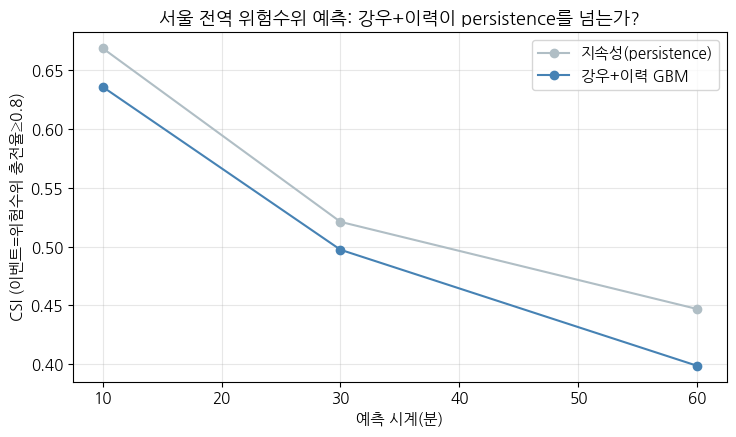

saved


In [4]:
fig,ax=plt.subplots(figsize=(7.5,4.5))
for nm,c in [('persistence','#b0bec5'),('강우+이력 GBM','steelblue')]:
    s=R[R.model==nm]; ax.plot(s.horizon,s.CSI,'o-',c=c,label='지속성(persistence)' if nm=='persistence' else nm)
ax.set_xlabel('예측 시계(분)'); ax.set_ylabel('CSI (이벤트=위험수위 충전율≥0.8)')
ax.set_title('서울 전역 위험수위 예측: 강우+이력이 persistence를 넘는가?')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout()
os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/06_seoul_danger_csi.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론
- 강우+이력 GBM이 persistence를 CSI에서 **넘으면** → 위험수위 예측 모델 라인 확정(특히 30~60분 리드).
- **못 넘으면** → 위험수위도 직전값이 최선 → 예측보다 데이터(라벨/하천/레이더) 확보가 우선.